## 1. Prep Data for Combined UMAP

In [1]:
import pandas as pd

In [2]:
REAL_XY_PATH = "../real_vase_data/all_profiles_120526.parquet"
GAME_XY_PATH = "../file_processing/processed/xy_data.parquet"
METADATA_PATH = "../real_vase_data/master_metadata.csv"

In [17]:
real_xy_df = pd.read_parquet(REAL_XY_PATH)
game_xy_df = pd.read_parquet(GAME_XY_PATH)

real_xy_df.rename(columns={'gpp_no': 'vase_id'}, inplace=True)

game_xy_df["vase_id"] = (
    game_xy_df["participant_id"].astype(str)
    + "::"
    + game_xy_df["generation_key"].astype(str)
    + "::"
    + game_xy_df["vase"].astype(str)
)

In [20]:
real_xy_df['source'] = 'real'
real_xy_df.head()

,vase_id,x,y,point_order,source
0,amph_1002176,-0.012187,1.5,0,real
1,amph_1002176,0.025235,1.5,1,real
2,amph_1002176,0.062658,1.5,2,real
3,amph_1002176,0.100081,1.5,3,real
4,amph_1002176,0.137504,1.5,4,real


In [21]:
game_xy_df['source'] = 'game'
game_xy_df.head()

,generation_key,vase,x,y,is_selected_vase,is_parent_vase,selection_elapsed_time_s,decision_time_ms,adjusted_selection_elapsed_time_s,adjusted_decision_time_ms,...,rt_calibration_trials_n,participant_id,session_id,play_counter,metadata_schema_version,session_started_at,session_duration_s,completion_status,vase_id,source
0,round_0_gen_1,vase_1,0.000650,1.977799,True,False,7.435,7435,7.427,7427.0,...,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,game
1,round_0_gen_1,vase_1,0.046236,1.977766,True,False,7.435,7435,7.427,7427.0,...,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,game
2,round_0_gen_1,vase_1,0.091811,1.977784,True,False,7.435,7435,7.427,7427.0,...,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,game
3,round_0_gen_1,vase_1,0.137535,1.977849,True,False,7.435,7435,7.427,7427.0,...,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,game
4,round_0_gen_1,vase_1,0.183402,1.978020,True,False,7.435,7435,7.427,7427.0,...,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,game


In [8]:
REAL_PC_PATH = "../file_processing/pca_csv/pca_scores.csv"
GAME_PC_PATH = "../file_processing/processed/pc_data.parquet"

In [9]:
real_df = pd.read_csv(REAL_PC_PATH)
real_df.rename(columns={'gpp_no': 'vase_id'}, inplace=True)
real_df['source'] = 'real'
real_df.drop(columns=['umap_x', 'umap_y'], inplace=True, errors='ignore')
print(f'Real latent DataFrame shape: {real_df.shape}')
real_df.head()

Real latent DataFrame shape: (53152, 9)


,PC1,PC2,PC3,PC4,PC5,PC6,vase_id,culture_general,source
0,-0.163041,-3.458043,-1.582309,0.180307,-0.656932,0.248755,af_1,african_subsaharan,real
1,-2.168747,-4.221789,2.044109,0.086909,0.467160,-0.121844,af_10,african_subsaharan,real
2,-5.391435,2.412122,4.583059,1.323759,0.873868,0.566609,af_101,african_subsaharan,real
3,-4.489663,0.801138,4.050509,1.658393,1.123359,0.264436,af_102,african_subsaharan,real
4,5.143272,-0.405920,0.831069,-0.739200,0.049908,-0.244080,af_103,african_subsaharan,real


In [10]:
game_df = pd.read_parquet(GAME_PC_PATH)
game_df['source'] = 'game'
game_df.drop(columns=['umap_x', 'umap_y'], inplace=True, errors='ignore')
print(f'Game latent DataFrame shape: {game_df.shape}')
game_df.head()

Game latent DataFrame shape: (299700, 22)


,generation_key,vase,pc_name,pc_value,is_selected_vase,is_parent_vase,selection_elapsed_time_s,decision_time_ms,adjusted_selection_elapsed_time_s,adjusted_decision_time_ms,...,rt_calibration_median_ms,rt_calibration_trials_n,participant_id,session_id,play_counter,metadata_schema_version,session_started_at,session_duration_s,completion_status,source
0,round_0_gen_1,vase_1,PC1,-8.587790,True,False,7.435,7435,7.427,7427.0,...,690.0,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,game
1,round_0_gen_1,vase_1,PC2,-2.160018,True,False,7.435,7435,7.427,7427.0,...,690.0,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,game
2,round_0_gen_1,vase_1,PC3,7.048562,True,False,7.435,7435,7.427,7427.0,...,690.0,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,game
3,round_0_gen_1,vase_1,PC4,0.729507,True,False,7.435,7435,7.427,7427.0,...,690.0,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,game
4,round_0_gen_1,vase_1,PC5,-0.235983,True,False,7.435,7435,7.427,7427.0,...,690.0,8,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1,1,1.778869e+09,119.029303,completed,game


In [11]:
game_df["vase_id"] = (
    game_df["participant_id"].astype(str)
    + "::"
    + game_df["generation_key"].astype(str)
    + "::"
    + game_df["vase"].astype(str)
)

In [12]:
game_pc_wide = (
    game_df
    .pivot_table(index='vase_id', columns='pc_name', values='pc_value', aggfunc='first')
    .reset_index()
)
game_pc_wide.columns.name = None
game_pc_wide['source'] = 'game'
game_pc_wide['culture_general'] = None  # not available for game vases

pc_cols = sorted([c for c in game_pc_wide.columns if c.startswith('PC')])
game_pc_wide = game_pc_wide[pc_cols + ['vase_id', 'culture_general', 'source']]

print(f'Game PC wide shape: {game_pc_wide.shape}')
print(f'Real PC shape:      {real_df.shape}')
game_pc_wide.head()

Game PC wide shape: (49950, 9)
Real PC shape:      (53152, 9)


,PC1,PC2,PC3,PC4,PC5,PC6,vase_id,culture_general,source
0,9.883250,-6.157681,-8.127982,1.210736,1.693825,1.650117,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,None,game
1,-0.479718,-0.504974,4.020295,-1.228403,2.710329,-2.085182,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,None,game
2,-0.479718,-0.504974,4.020295,-1.228403,2.710329,-2.085182,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,None,game
3,4.543278,-7.145483,2.446911,0.809820,2.901232,-1.336040,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,None,game
4,-0.479718,-0.504974,4.020295,-1.228403,2.710329,-2.085182,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...,None,game


In [13]:
real_latent_df = real_df[[ c for c in real_df.columns if c.startswith('PC') ]]
real_latent_df['source'] = 'real'
real_latent_df['vase_id'] = real_df['vase_id']
real_latent_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,source,vase_id
0,-0.163041,-3.458043,-1.582309,0.180307,-0.656932,0.248755,real,af_1
1,-2.168747,-4.221789,2.044109,0.086909,0.467160,-0.121844,real,af_10
2,-5.391435,2.412122,4.583059,1.323759,0.873868,0.566609,real,af_101
3,-4.489663,0.801138,4.050509,1.658393,1.123359,0.264436,real,af_102
4,5.143272,-0.405920,0.831069,-0.739200,0.049908,-0.244080,real,af_103


In [14]:
game_latent_df = game_pc_wide[[ c for c in game_pc_wide.columns if c.startswith('PC') ]]
game_latent_df['source'] = 'game'
game_latent_df['vase_id'] = game_pc_wide['vase_id']
game_latent_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,source,vase_id
0,9.883250,-6.157681,-8.127982,1.210736,1.693825,1.650117,game,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...
1,-0.479718,-0.504974,4.020295,-1.228403,2.710329,-2.085182,game,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...
2,-0.479718,-0.504974,4.020295,-1.228403,2.710329,-2.085182,game,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...
3,4.543278,-7.145483,2.446911,0.809820,2.901232,-1.336040,game,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...
4,-0.479718,-0.504974,4.020295,-1.228403,2.710329,-2.085182,game,008e7cb7-6043-458b-870a-f3ec08d461e9::round_0_...


In [15]:
latent_df = pd.concat([real_latent_df, game_latent_df], ignore_index=True)
print(f'Combined latent DataFrame shape: {latent_df.shape}')
print(latent_df['source'].value_counts())
latent_df.head()

Combined latent DataFrame shape: (103102, 8)
source
real    53152
game    49950
Name: count, dtype: int64


,PC1,PC2,PC3,PC4,PC5,PC6,source,vase_id
0,-0.163041,-3.458043,-1.582309,0.180307,-0.656932,0.248755,real,af_1
1,-2.168747,-4.221789,2.044109,0.086909,0.467160,-0.121844,real,af_10
2,-5.391435,2.412122,4.583059,1.323759,0.873868,0.566609,real,af_101
3,-4.489663,0.801138,4.050509,1.658393,1.123359,0.264436,real,af_102
4,5.143272,-0.405920,0.831069,-0.739200,0.049908,-0.244080,real,af_103


## 2. Optimise UMAP Projection

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import umap.umap_ as umap
from sklearn.manifold import trustworthiness
from tqdm import tqdm

/Users/joshmt/theperfectpot_analysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# [LATENT] Process all latent dimensions into an array for UMAP
latent_cols = [ c for c in latent_df.columns if c.startswith('PC') ]
latent_array = latent_df[latent_cols].values
print(f'Latent array shape: {latent_array.shape}')

In [33]:
def build_xy_feature_matrix(df, id_col='vase_id', order_col='point_order'):
    rows, ids, sources = [], [], []
    for (vase_id, source), grp in df.groupby([id_col, 'source'], sort=False):
        grp_sorted = grp.sort_values(order_col) if order_col in grp.columns else grp
        x = grp_sorted['x'].to_numpy(dtype=np.float32)
        y = grp_sorted['y'].to_numpy(dtype=np.float32)
        rows.append(np.concatenate([x, y]))
        ids.append(vase_id)
        sources.append(source)
    return np.stack(rows), pd.DataFrame({'vase_id': ids, 'source': sources})

xy_matrix_real, meta_real = build_xy_feature_matrix(real_xy_df)
xy_matrix_game, meta_game = build_xy_feature_matrix(game_xy_df)

# Toggle: use both sources or just game for testing
TEST_GAME_ONLY = False

if TEST_GAME_ONLY:
    xy_array = xy_matrix_game
    xy_meta_df = meta_game
else:
    xy_array = np.vstack([xy_matrix_real, xy_matrix_game])
    xy_meta_df = pd.concat([meta_real, meta_game], ignore_index=True)

print(f'XY feature matrix shape: {xy_array.shape}')
print(xy_meta_df['source'].value_counts())

XY feature matrix shape: (157427, 500)
source
real    107477
game     49950
Name: count, dtype: int64


In [24]:
def umap_calibration(latent_matrix, sample_size=15000, n_neighbors_test = [15, 50, 150, 200], min_dist_test = [0.01, 0.1, 0.5]):
    np.random.seed(42)
    indices = np.random.choice(latent_matrix.shape[0], sample_size, replace=False)
    X_sample = latent_matrix[indices]
    
    fig, axes = plt.subplots(len(n_neighbors_test), len(min_dist_test), figsize=(18, 18))
    fig.subplots_adjust(hspace=0.3, wspace=0.3)
    
    best_score = 0
    best_params = {}
        
    for i, n_n in tqdm(enumerate(n_neighbors_test), total=len(n_neighbors_test)):
        for j, m_d in tqdm(enumerate(min_dist_test), total=len(min_dist_test)):
            print(f"   -> Testing: n_neighbors={n_n}, min_dist={m_d}")
            
            reducer = umap.UMAP(
                n_components=2, 
                n_neighbors=n_n, 
                min_dist=m_d, 
                metric='euclidean', 
                random_state=42
            )
            umap_coords = reducer.fit_transform(X_sample)
            
            # Trustworthiness measures to what extent the local structure is retained.
            # A score of 1.0 means the 2D map perfectly represents the true latent dimensions' local relationships.
            score = trustworthiness(X_sample, umap_coords, n_neighbors=n_n)
            
            if score > best_score:
                best_score = score
                best_params = {'n_neighbors': n_n, 'min_dist': m_d}
            
            ax = axes[i, j]
            ax.scatter(umap_coords[:, 0], umap_coords[:, 1], s=1, alpha=0.3, c='black')
            ax.set_title(f"n_neighbors: {n_n} | min_dist: {m_d}\nTrustworthiness: {score:.4f}", fontsize=12)
            ax.set_xticks([])
            ax.set_yticks([])
            
    plt.suptitle("UMAP Hyperparameter Topologies (15k Sample)", fontsize=20, y=0.92)
    plt.savefig("umap_calibration_grid.png", dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"   MATHEMATICAL OPTIMUM: n_neighbors={best_params['n_neighbors']}, min_dist={best_params['min_dist']} (Score: {best_score:.4f})")
    
    return best_params

In [ ]:
n_neighbors_test = [150, 200, 300] 
min_dist_test = [0.01, 0.02, 0.05]

In [ ]:
# [XY] Run calibration on XY feature matrix instead of latent array
optimal_params = umap_calibration(latent_array, sample_size=15000, n_neighbors_test=n_neighbors_test, min_dist_test=min_dist_test)
print(f"Optimal UMAP Parameters: {optimal_params}")

In [ ]:
# n_n_opt = optimal_params['n_neighbors']
# m_d_opt = optimal_params['min_dist']

In [26]:
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=200,
    min_dist=0.02,
    metric='euclidean',
    random_state=42,
)
embedding = reducer.fit_transform(xy_array) 
print('UMAP embedding shape:', embedding.shape)

/Users/joshmt/theperfectpot_analysis/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


UMAP embedding shape: (157427, 2)


In [34]:
umap_x = embedding[:, 0]
umap_y = embedding[:, 1]
xy_meta_df = xy_meta_df.copy()
xy_meta_df['umap_x'] = umap_x
xy_meta_df['umap_y'] = umap_y
xy_meta_df.head()

,vase_id,source,umap_x,umap_y
0,amph_1002176,real,13.905229,5.148390
1,amph_302169,real,15.797910,5.466938
2,amph_302252,real,15.677945,5.218333
3,amph_310339,real,15.954820,5.041158
4,amph_310393_2,real,16.055964,5.192517


In [35]:
master_df = pd.concat([real_df, game_df], ignore_index=True)
print(f'Master DataFrame shape: {master_df.shape}')
print(master_df.columns)
master_df.head()

Master DataFrame shape: (352852, 30)
Index(['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'vase_id', 'culture_general',
       'source', 'generation_key', 'vase', 'pc_name', 'pc_value',
       'is_selected_vase', 'is_parent_vase', 'selection_elapsed_time_s',
       'decision_time_ms', 'adjusted_selection_elapsed_time_s',
       'adjusted_decision_time_ms', 'rt_onset_correction_ms',
       'rt_calibration_status', 'rt_calibration_median_ms',
       'rt_calibration_trials_n', 'participant_id', 'session_id',
       'play_counter', 'metadata_schema_version', 'session_started_at',
       'session_duration_s', 'completion_status'],
      dtype='str')


,PC1,PC2,PC3,PC4,PC5,PC6,vase_id,culture_general,source,generation_key,...,rt_calibration_status,rt_calibration_median_ms,rt_calibration_trials_n,participant_id,session_id,play_counter,metadata_schema_version,session_started_at,session_duration_s,completion_status
0,-0.163041,-3.458043,-1.582309,0.180307,-0.656932,0.248755,af_1,african_subsaharan,real,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-2.168747,-4.221789,2.044109,0.086909,0.467160,-0.121844,af_10,african_subsaharan,real,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-5.391435,2.412122,4.583059,1.323759,0.873868,0.566609,af_101,african_subsaharan,real,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-4.489663,0.801138,4.050509,1.658393,1.123359,0.264436,af_102,african_subsaharan,real,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.143272,-0.405920,0.831069,-0.739200,0.049908,-0.244080,af_103,african_subsaharan,real,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
# Add the UMAP coordinates to the master DataFrame
# [XY] was: master_df.merge(latent_df[['vase_id', 'source', 'umap_x', 'umap_y']], ...)
master_df = master_df.merge(xy_meta_df[['vase_id', 'source', 'umap_x', 'umap_y']], on=['vase_id', 'source'], how='left')
print(f'Master DataFrame with UMAP shape: {master_df.shape}')
print(master_df.columns)
master_df.head()

Master DataFrame with UMAP shape: (352852, 32)
Index(['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'vase_id', 'culture_general',
       'source', 'generation_key', 'vase', 'pc_name', 'pc_value',
       'is_selected_vase', 'is_parent_vase', 'selection_elapsed_time_s',
       'decision_time_ms', 'adjusted_selection_elapsed_time_s',
       'adjusted_decision_time_ms', 'rt_onset_correction_ms',
       'rt_calibration_status', 'rt_calibration_median_ms',
       'rt_calibration_trials_n', 'participant_id', 'session_id',
       'play_counter', 'metadata_schema_version', 'session_started_at',
       'session_duration_s', 'completion_status', 'umap_x', 'umap_y'],
      dtype='str')


,PC1,PC2,PC3,PC4,PC5,PC6,vase_id,culture_general,source,generation_key,...,rt_calibration_trials_n,participant_id,session_id,play_counter,metadata_schema_version,session_started_at,session_duration_s,completion_status,umap_x,umap_y
0,-0.163041,-3.458043,-1.582309,0.180307,-0.656932,0.248755,af_1,african_subsaharan,real,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.381421,0.831381
1,-2.168747,-4.221789,2.044109,0.086909,0.467160,-0.121844,af_10,african_subsaharan,real,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.256351,0.586361
2,-5.391435,2.412122,4.583059,1.323759,0.873868,0.566609,af_101,african_subsaharan,real,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.624378,5.914351
3,-4.489663,0.801138,4.050509,1.658393,1.123359,0.264436,af_102,african_subsaharan,real,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.032199,5.516442
4,5.143272,-0.405920,0.831069,-0.739200,0.049908,-0.244080,af_103,african_subsaharan,real,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.008078,-0.721337


## 3. Plot UMAP Projections

In [44]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import numpy as np

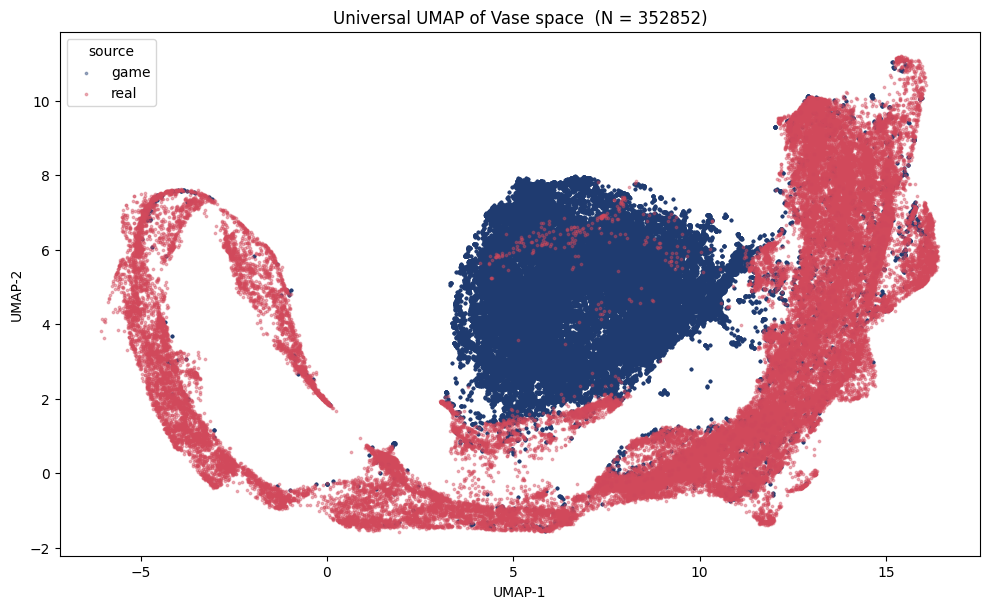

In [49]:
fig, ax = plt.subplots(figsize=(10, 10))
colors = {'game': '#1f3b70', 'real': '#d1495b'}
for source, sub in master_df.groupby('source'):
    ax.scatter(sub['umap_x'], sub['umap_y'], s=3, alpha=0.4, color=colors.get(source, 'gray'), label=source)
ax.legend(title='source')
ax.set_title(f'Universal UMAP of Vase space  (N = {len(master_df)})')
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

In [46]:
# Build normalized contour dictionary directly from XY profile tables.
real_xy_for_plot = real_xy_df.rename(columns={'gpp_no': 'vase_id'})[['vase_id', 'x', 'y']].copy()
real_xy_for_plot['source'] = 'real'

game_cols = ['vase_id', 'x', 'y'] + (['coord_order'] if 'coord_order' in game_xy_df.columns else [])
game_xy_for_plot = game_xy_df[game_cols].copy()
game_xy_for_plot['source'] = 'game'

xy_for_plot = pd.concat([real_xy_for_plot, game_xy_for_plot], ignore_index=True)

xy_for_plot.head()

,vase_id,x,y,source
0,amph_1002176,-0.012187,1.5,real
1,amph_1002176,0.025235,1.5,real
2,amph_1002176,0.062658,1.5,real
3,amph_1002176,0.100081,1.5,real
4,amph_1002176,0.137504,1.5,real


In [47]:
contours_by_key = {}
for (src, vase_id), grp in xy_for_plot.groupby(['source', 'vase_id'], sort=False):
    if 'coord_order' in grp.columns:
        grp = grp.sort_values('coord_order')

    x = grp['x'].to_numpy(dtype=float)
    y = grp['y'].to_numpy(dtype=float)
    if len(x) < 3:
        continue

    # Ensure closed polygon for clean fills.
    if x[0] != x[-1] or y[0] != y[-1]:
        x = np.append(x, x[0])
        y = np.append(y, y[0])

    # Normalize each vase profile to fit the draw cell consistently.
    x = x - np.nanmean(x)
    y = y - np.nanmean(y)
    scale = max(np.nanmax(np.abs(x)), np.nanmax(np.abs(y)), 1e-9)
    x = x / scale
    y = y / scale

    contours_by_key[(src, vase_id)] = np.vstack([x, y])

In [60]:
def plot_vase_umap_grid(plot_df, contours, title=None, save_path=None, N=50,
                        source_colors=None):
    if source_colors is None:
        source_colors = {'real': '#d1495b', 'game': '#1f3b70'}

    df = plot_df.dropna(subset=['umap_x', 'umap_y']).reset_index(drop=True)
    xs = df['umap_x'].to_numpy()
    ys = df['umap_y'].to_numpy()

    x_min, x_max = xs.min(), xs.max()
    y_min, y_max = ys.min(), ys.max()
    cell_w = (x_max - x_min) / N
    cell_h = (y_max - y_min) / N

    col_idx = np.clip(((xs - x_min) / cell_w).astype(int), 0, N - 1)
    row_idx = np.clip(((ys - y_min) / cell_h).astype(int), 0, N - 1)

    cell_rep = {}
    for i, (ri, ci) in enumerate(zip(row_idx, col_idx)):
        cx = x_min + (ci + 0.5) * cell_w
        cy = y_min + (ri + 0.5) * cell_h
        d2 = (xs[i] - cx) ** 2 + (ys[i] - cy) ** 2
        if (ri, ci) not in cell_rep or d2 < cell_rep[(ri, ci)][0]:
            cell_rep[(ri, ci)] = (d2, i, cx, cy)

    draw_scale = cell_w * 0.30
    fig, ax = plt.subplots(figsize=(14, 14), dpi=150)
    ax.scatter(xs, ys, s=1, color='lightgrey', alpha=0.15, zorder=1, rasterized=True)

    for (ri, ci), (_, pt_idx, cx, cy) in cell_rep.items():
        row = df.iloc[pt_idx]
        src, vase_id = row['source'], row['vase_id']
        contour = contours.get((src, vase_id))
        if contour is None:
            continue
        ax.fill(cx + contour[0] * draw_scale, cy + contour[1] * draw_scale,
                color=source_colors.get(src, 'gray'), alpha=0.85, edgecolor='none', zorder=2)

    legend_handles = [Patch(facecolor=c, edgecolor='none', label=s)
                      for s, c in source_colors.items() if s in df['source'].values]
    ax.legend(handles=legend_handles, title='source', frameon=False)
    ax.set_aspect('equal')
    ax.set_xlabel('UMAP 1', fontweight='bold', labelpad=10)
    ax.set_ylabel('UMAP 2', fontweight='bold', labelpad=10)
    ax.spines[['top', 'right']].set_visible(False)
    if title:
        ax.set_title(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

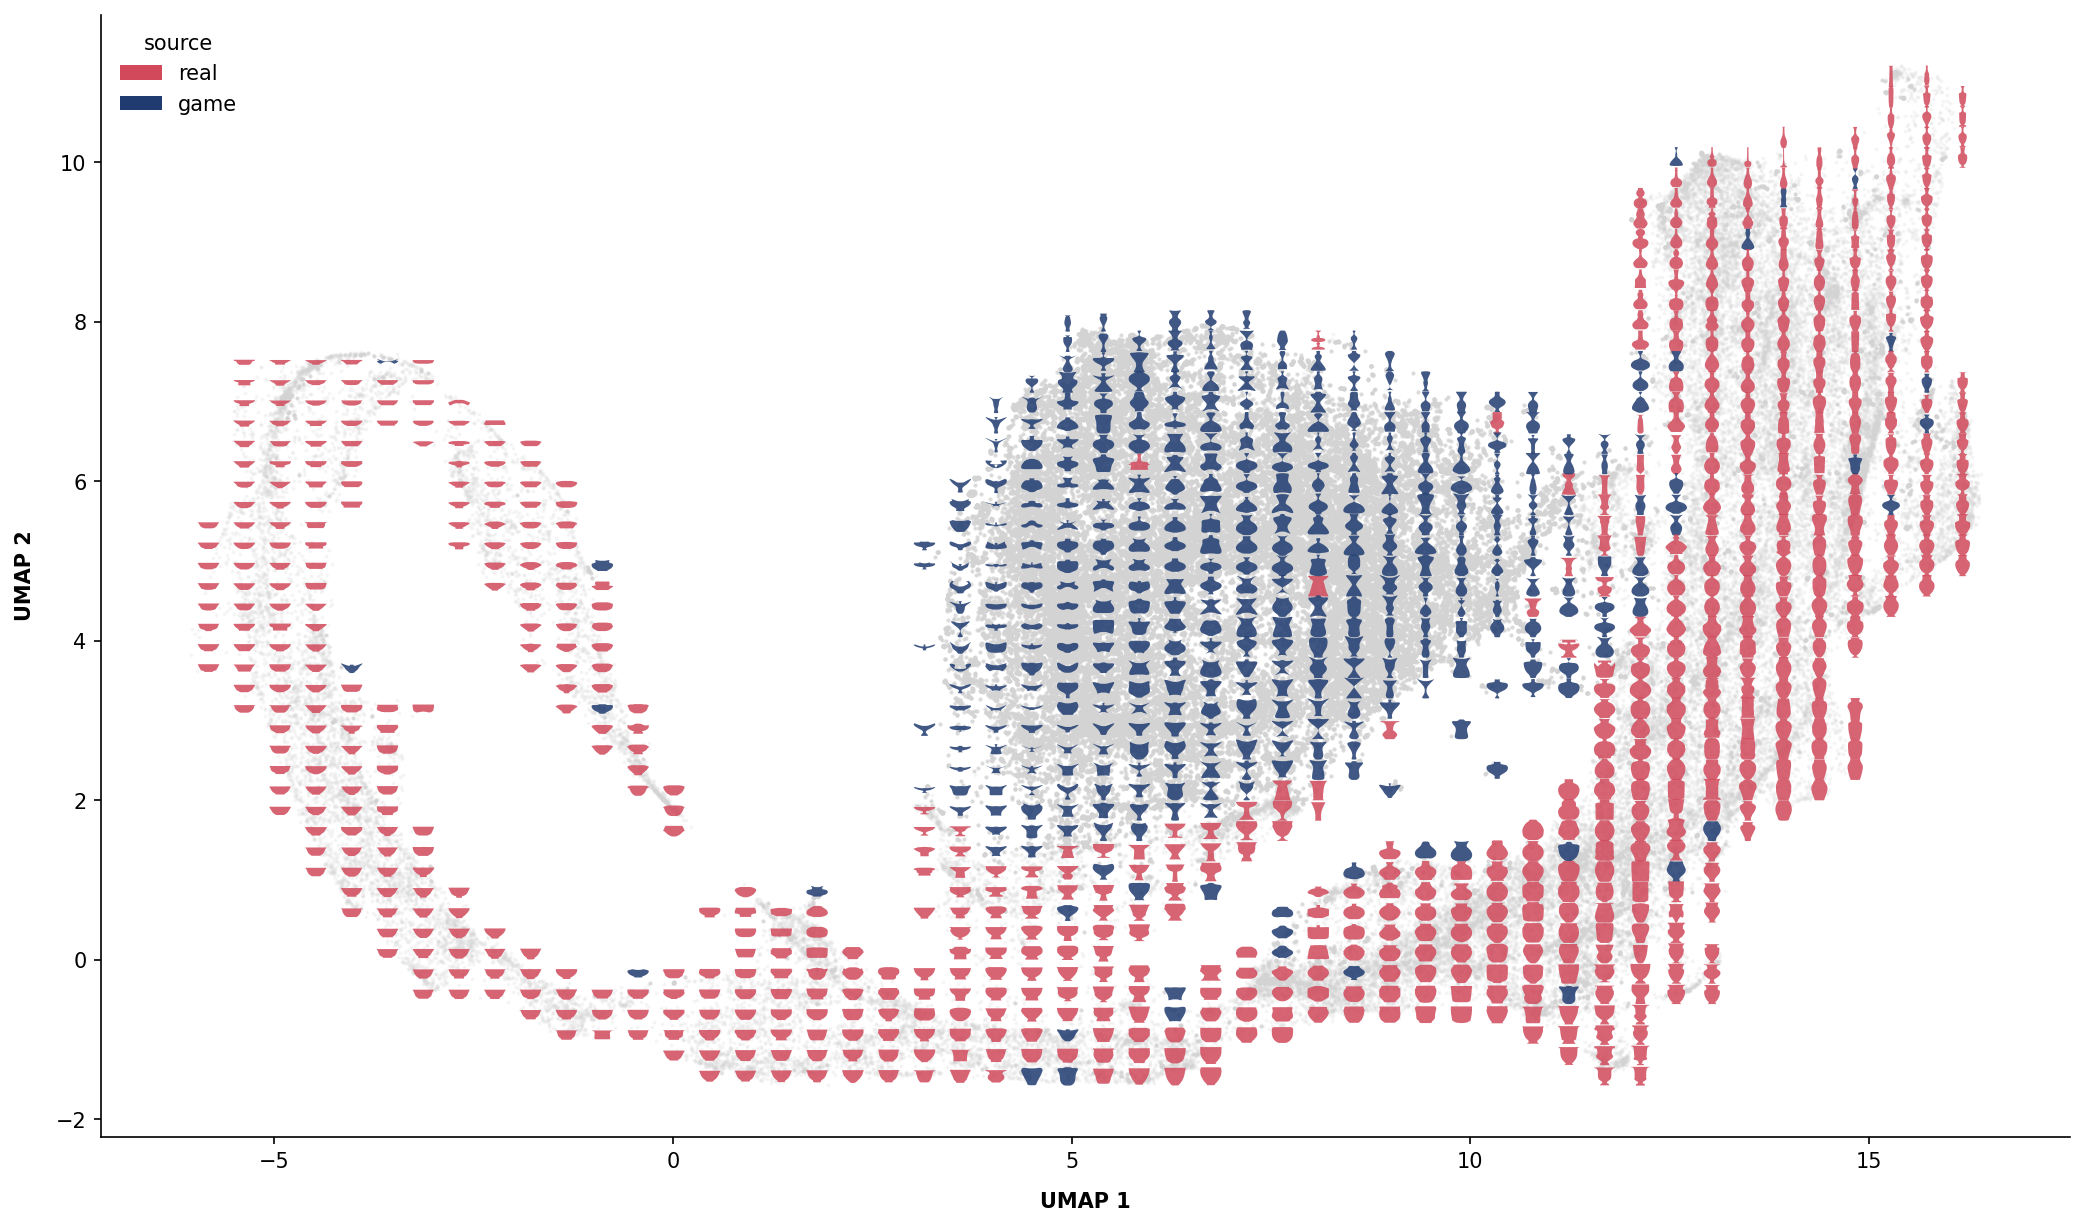

In [61]:
plot_vase_umap_grid(master_df, contours_by_key, save_path='vase_umap_grid.svg')

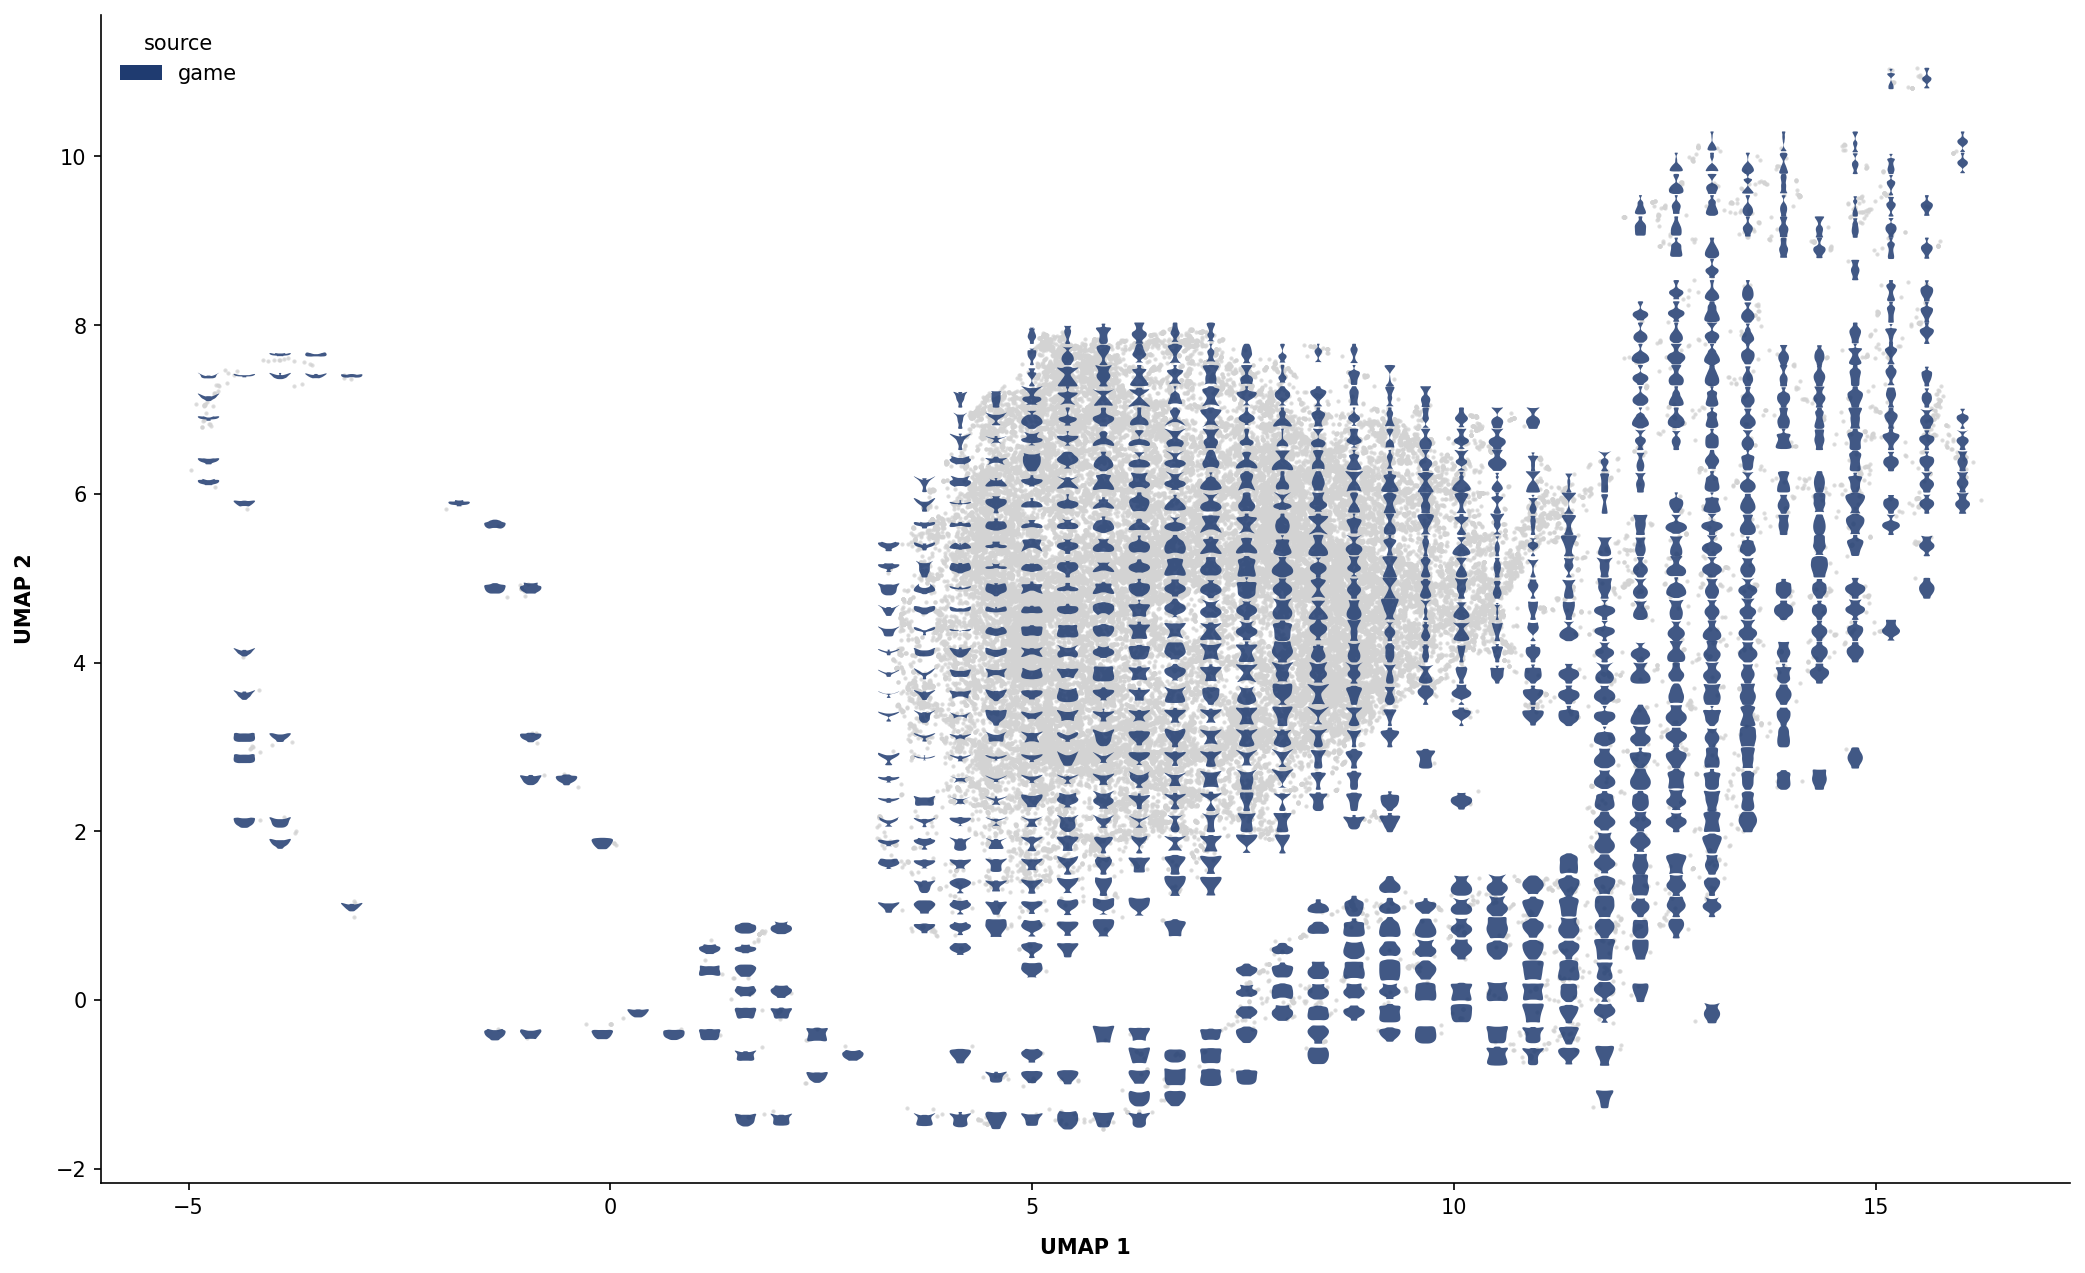

In [62]:
plot_vase_umap_grid(master_df[master_df['source'] == 'game'], contours_by_key, save_path='game_vase_umap_grid.svg')

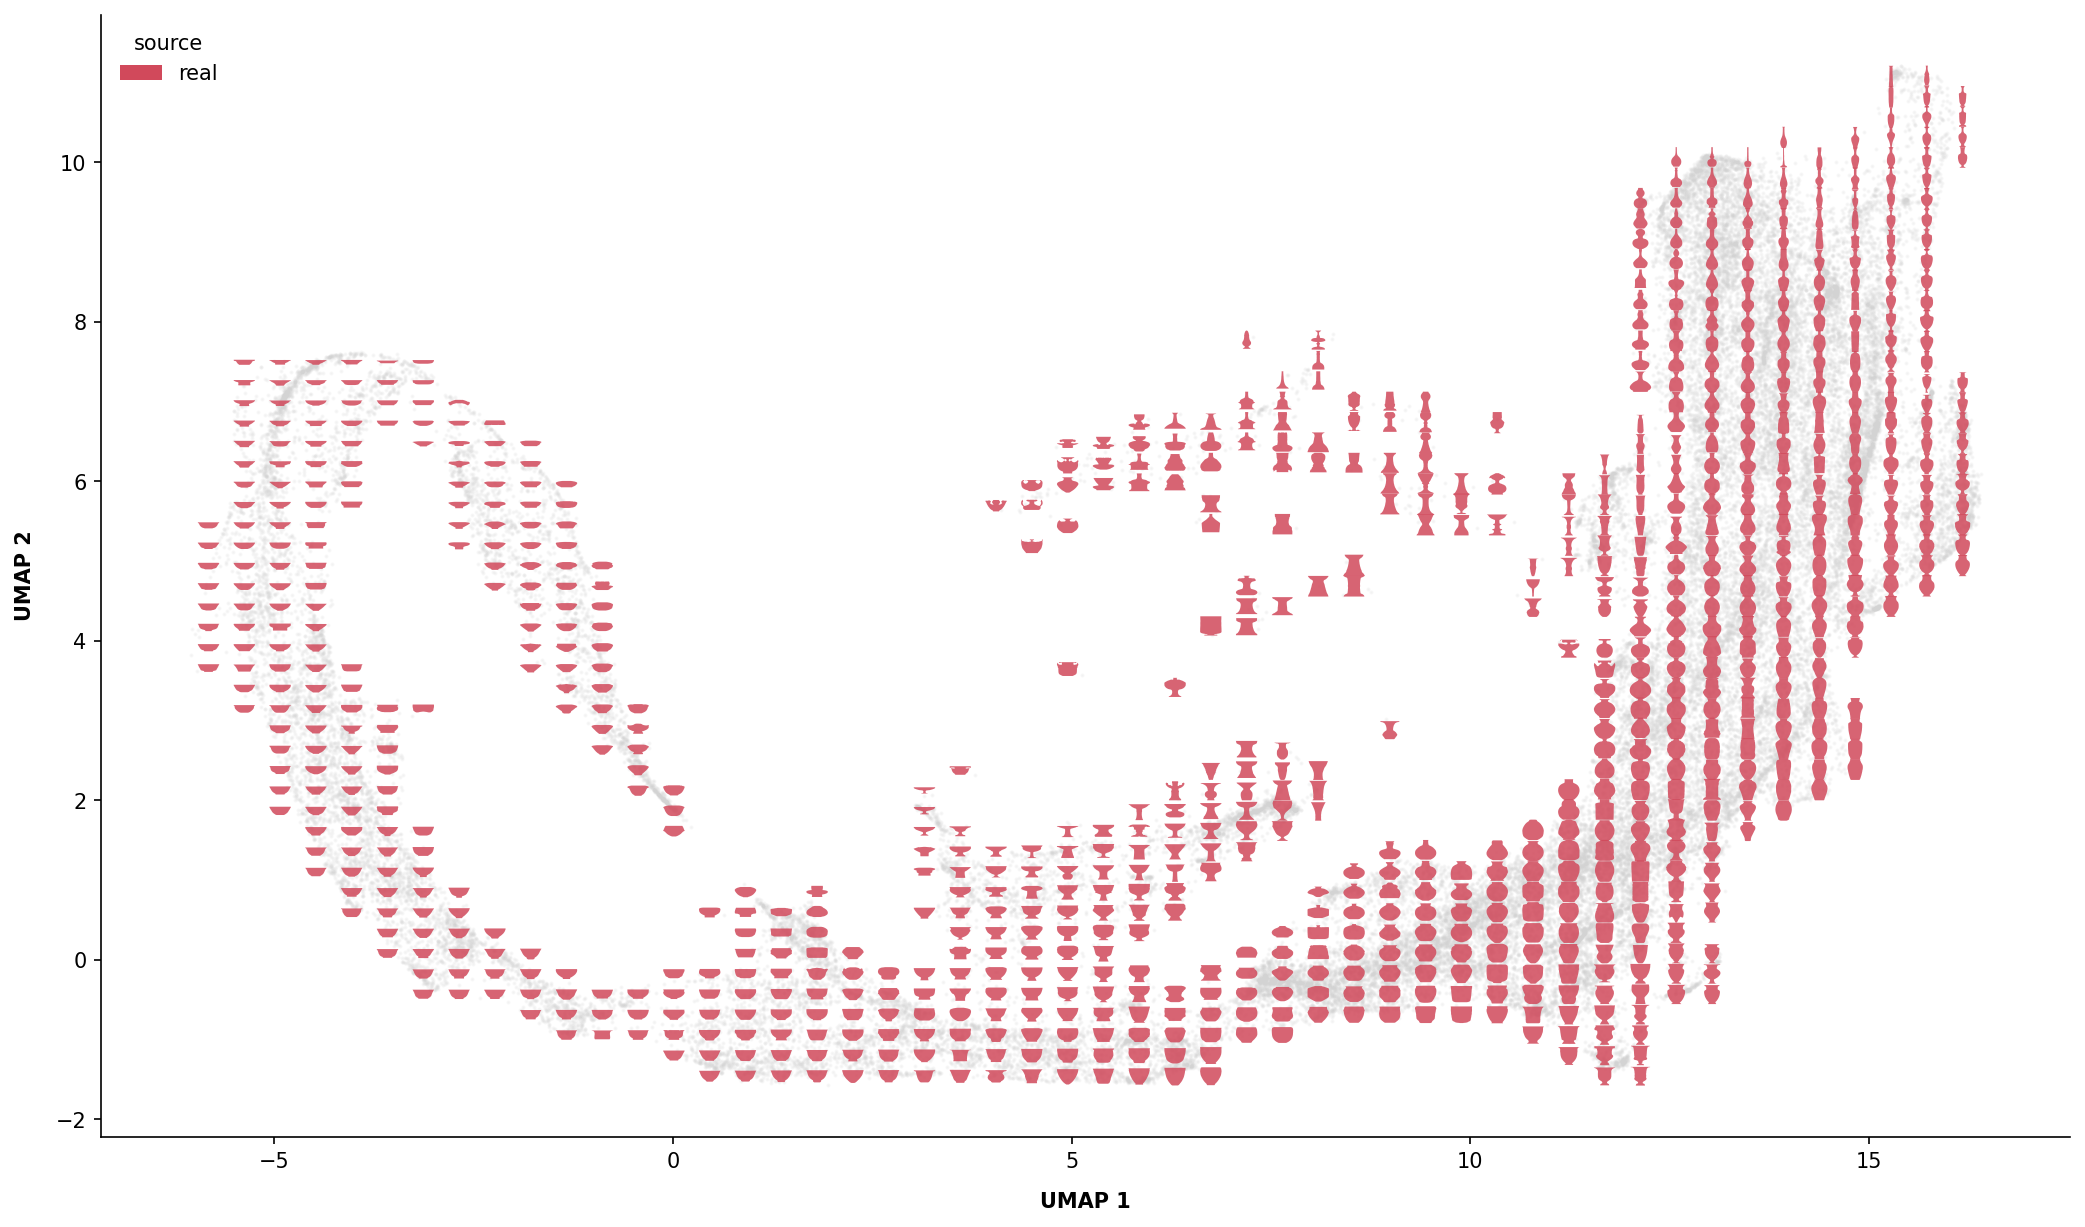

In [63]:
plot_vase_umap_grid(master_df[master_df['source'] == 'real'], contours_by_key, save_path='real_vase_umap_grid.svg')

## 4. Save the UMAP Dataframes

In [38]:
import os

In [39]:
SAVE_DIR = "umap_projections"
REAL_SAVE_PATH = os.path.join(SAVE_DIR, "real_vase_umap_projection.parquet")
GAME_SAVE_PATH = os.path.join(SAVE_DIR, "game_vase_umap_projection.parquet")
MASTER_SAVE_PATH = os.path.join(SAVE_DIR, "combined_vase_umap_projection.parquet")

In [40]:
os.makedirs(SAVE_DIR, exist_ok=True)
master_df.to_parquet(MASTER_SAVE_PATH, index=False)

In [41]:
real_umap_df = master_df[master_df['source'] == 'real']
real_umap_df.drop([col for col in real_umap_df.columns if col.startswith('z')], axis=1, inplace=True, errors='ignore')
real_umap_df.drop(columns=['source', "generation", "vase", "gen_selected_vase", "elapsed_time", 
                           "ancestral_region", "youth_region", "disability", "user_id", "play_counter", 
                           "round", "user_round_generation", "potter", "age", "gender", "sexuality"], inplace=True, errors='ignore')
real_umap_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,vase_id,culture_general,generation_key,pc_name,...,rt_calibration_median_ms,rt_calibration_trials_n,participant_id,session_id,metadata_schema_version,session_started_at,session_duration_s,completion_status,umap_x,umap_y
0,-0.163041,-3.458043,-1.582309,0.180307,-0.656932,0.248755,af_1,african_subsaharan,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.381421,0.831381
1,-2.168747,-4.221789,2.044109,0.086909,0.467160,-0.121844,af_10,african_subsaharan,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.256351,0.586361
2,-5.391435,2.412122,4.583059,1.323759,0.873868,0.566609,af_101,african_subsaharan,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.624378,5.914351
3,-4.489663,0.801138,4.050509,1.658393,1.123359,0.264436,af_102,african_subsaharan,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.032199,5.516442
4,5.143272,-0.405920,0.831069,-0.739200,0.049908,-0.244080,af_103,african_subsaharan,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.008078,-0.721337


In [42]:
game_umap_df = master_df[master_df['source'] == 'game']
game_umap_df.drop([col for col in game_umap_df.columns if col.startswith('z')], axis=1, inplace=True, errors='ignore')
game_umap_df.drop(columns=["culture_general", "culture_specific", "continent_made_found", "country_made_found"], inplace=True, errors='ignore')
game_umap_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,vase_id,source,generation_key,vase,...,rt_calibration_trials_n,participant_id,session_id,play_counter,metadata_schema_version,session_started_at,session_duration_s,completion_status,umap_x,umap_y
53152,NaN,NaN,NaN,NaN,NaN,NaN,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,game,round_0_gen_1,vase_1,...,8.0,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1.0,1.0,1.778869e+09,119.029303,completed,9.628722,4.289236
53153,NaN,NaN,NaN,NaN,NaN,NaN,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,game,round_0_gen_1,vase_1,...,8.0,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1.0,1.0,1.778869e+09,119.029303,completed,9.628722,4.289236
53154,NaN,NaN,NaN,NaN,NaN,NaN,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,game,round_0_gen_1,vase_1,...,8.0,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1.0,1.0,1.778869e+09,119.029303,completed,9.628722,4.289236
53155,NaN,NaN,NaN,NaN,NaN,NaN,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,game,round_0_gen_1,vase_1,...,8.0,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1.0,1.0,1.778869e+09,119.029303,completed,9.628722,4.289236
53156,NaN,NaN,NaN,NaN,NaN,NaN,01553c98-79fa-475e-a939-772f9f3d5e18::round_0_...,game,round_0_gen_1,vase_1,...,8.0,01553c98-79fa-475e-a939-772f9f3d5e18,89013e10-fd8e-4c68-a2fb-f3917c35a895,1.0,1.0,1.778869e+09,119.029303,completed,9.628722,4.289236


In [43]:
real_umap_df.to_parquet(REAL_SAVE_PATH, index=False)
game_umap_df.to_parquet(GAME_SAVE_PATH, index=False)